# 03 · MNIST final training

Notebook này đọc thư mục dataset, train mọi model trong `MODEL_CONFIGS`, lưu file weight và đánh giá trên validation/test.

In [1]:
from pathlib import Path
import sys
import json
from time import perf_counter
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'gk' / 'web' / 'backend').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from gk.web.backend.digits_config import (
    DATASET_DIR, DATASET_PATH, MODEL_ARTIFACT_PATH, MODEL_CONFIG_PATH, RAW_DATASET_PATH,
    PIXEL_COUNT, PIXEL_SIZE, SPLIT_PATH, WEIGHTS_PATH,
)
from gk.web.backend.digits_models import build_logistic, build_mlp, export_layers, model_metadata
from gk.web.backend.digits_augmentation import build_augmented_variants, repeat_labels
from gk.web.backend.model_config import (
    AUGMENT_FACTOR, AUGMENT_ROTATE_DEGREES, AUGMENT_SCALE_RANGE, AUGMENT_SHARPEN,
    AUGMENT_SHIFT_PIXELS, AUGMENT_STROKE_VARIANTS, AUGMENT_TRAINING,
    architecture_sizes, hidden_activation, hidden_layer_sizes, layer_activations,
)

CONFIG_PATH = MODEL_CONFIG_PATH
OUTPUT_PATH = WEIGHTS_PATH
TRAIN_LOG_PATH = DATASET_DIR / 'training_log.json'
WEB_OUTPUT_PATH = MODEL_ARTIFACT_PATH
print('Configured input:', f'{PIXEL_SIZE}x{PIXEL_SIZE} ({PIXEL_COUNT} features)')
data = np.load(DATASET_PATH)
raw_data = np.load(RAW_DATASET_PATH)
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f'Run mnist_models.ipynb first to create {CONFIG_PATH}')
config = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
X_train_images = data['X_train_pixels'].astype(float)
y_train = data['y_train'].astype(int)
X_test_images = data['X_test_pixels'].astype(float)
y_test = data['y_test'].astype(int)
X_train_pixels = X_train_images.reshape(len(X_train_images), -1)
X_test_pixels = X_test_images.reshape(len(X_test_images), -1)
split = json.loads(SPLIT_PATH.read_text(encoding='utf-8'))
fit_indices = np.asarray(split['fit_indices'], dtype=int)
validation_indices = np.asarray(split['validation_indices'], dtype=int)
raw_train_images = raw_data['X_train_images'].astype(float)
original_fit_pixels = X_train_pixels[fit_indices]
original_fit_labels = y_train[fit_indices]
if AUGMENT_TRAINING:
    augmented_pixels = build_augmented_variants(
        raw_train_images[fit_indices],
        factor=AUGMENT_FACTOR,
        shift_pixels=AUGMENT_SHIFT_PIXELS,
        stroke_variants=AUGMENT_STROKE_VARIANTS,
        scale_range=AUGMENT_SCALE_RANGE,
        rotate_degrees=AUGMENT_ROTATE_DEGREES,
        sharpen=AUGMENT_SHARPEN,
        seed=config['random_seed'],
    )
    fit_pixels = np.vstack((original_fit_pixels, augmented_pixels))
    y_fit = repeat_labels(original_fit_labels, AUGMENT_FACTOR)
else:
    augmented_pixels = np.empty((0, PIXEL_COUNT), dtype=np.float32)
    fit_pixels = original_fit_pixels
    y_fit = original_fit_labels
scaler = StandardScaler().fit(fit_pixels)
mean = scaler.mean_
std = scaler.scale_
config['scaler'] = {'mean': mean.tolist(), 'std': std.tolist()}
CONFIG_PATH.write_text(json.dumps(config, indent=2), encoding='utf-8')
X_fit = scaler.transform(fit_pixels)
X_validation = scaler.transform(X_train_pixels[validation_indices])
X_test = scaler.transform(X_test_pixels)
y_validation = y_train[validation_indices]
print('Loaded dataset and model config')
print(f'augmentation: {len(original_fit_pixels)} originals + {len(augmented_pixels)} variants = {len(X_fit)} train samples')


Loaded dataset and model config
augmentation: 48000 originals + 192000 variants = 240000 train samples


## Train bốn model và ghi log

Các config ở đây đến từ `mnist_model_config.json`, vì vậy có thể tối ưu notebook model mà không sửa notebook train. Log bên dưới lấy trực tiếp từ object đã fit.

In [2]:
model_configs = config['models']
trained = {}
training_log = []

def fit_and_log(model_id, model, model_config, kind):
    total = len(model_configs)
    print(f'\n[{len(training_log) + 1}/{total}] {model_id} · training')
    print('    config:', model_config)
    started = perf_counter()
    model.fit(X_fit, y_fit)
    elapsed = perf_counter() - started
    loss_curve = [float(value) for value in getattr(model, 'loss_curve_', [])]
    iterations = int(np.max(model.n_iter_)) if hasattr(model, 'n_iter_') else None
    max_iter = int(model_config.get('max_iter', iterations or 0))
    converged = iterations is None or iterations < max_iter
    record = {
        'model_id': model_id, 'kind': kind, 'status': 'completed',
        'elapsed_seconds': round(elapsed, 3),
        'iterations': iterations, 'epochs': len(loss_curve) or None,
        'initial_loss': loss_curve[0] if loss_curve else None,
        'final_loss': loss_curve[-1] if loss_curve else None,
        'loss_curve': loss_curve, 'converged': converged,
        'config': model_config,
    }
    training_log.append(record)
    print(f'    done in {elapsed:.2f}s · iterations={iterations} · epochs={record["epochs"]} · final_loss={record["final_loss"]} · status={"converged" if converged else "max_iter reached"}')
    return model

for model_id, model_config in model_configs.items():
    if model_config.get('kind') == 'linear':
        trained[model_id] = fit_and_log(
            model_id,
            build_logistic(model_config['C'], model_config.get('solver', 'lbfgs'), model_config.get('max_iter', 2000), verbose=1),
            model_config, 'linear',
        )
        continue
    trained[model_id] = fit_and_log(
        model_id,
        build_mlp(
            hidden_layer_sizes(model_config), hidden_activation(model_config),
            model_config['learning_rate_init'], model_config['max_iter'],
            model_config.get('early_stopping', False), model_config.get('n_iter_no_change'),
            model_config.get('batch_size'), verbose=True,
        ),
        model_config, 'ann',
    )

print('trained:', list(trained))


[1/4] logistic · training
    config: {'kind': 'linear', 'layers': [{'input': 256, 'output': 10, 'activation': 'softmax'}], 'C': 1.0, 'solver': 'lbfgs', 'max_iter': 300}
    done in 6.03s · iterations=142 · epochs=None · final_loss=None · status=converged

[2/4] mlp_4_one_layer · training
    config: {'kind': 'ann', 'layers': [{'input': 256, 'output': 8, 'activation': 'tanh'}, {'input': 8, 'output': 10, 'activation': 'softmax'}], 'learning_rate_init': 0.001, 'batch_size': 256, 'max_iter': 350, 'early_stopping': False}
Iteration 1, loss = 1.04829760
Iteration 2, loss = 0.68736082
Iteration 3, loss = 0.62871737
Iteration 4, loss = 0.60139997
Iteration 5, loss = 0.58491866
Iteration 6, loss = 0.57451261
Iteration 7, loss = 0.56674773
Iteration 8, loss = 0.56079778
Iteration 9, loss = 0.55633047
Iteration 10, loss = 0.55343330
Iteration 11, loss = 0.55091631
Iteration 12, loss = 0.54905975
Iteration 13, loss = 0.54779062
Iteration 14, loss = 0.54685960
Iteration 15, loss = 0.54567928
Iter

/Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (350) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 1.15877251
Iteration 2, loss = 0.69732984
Iteration 3, loss = 0.63511094
Iteration 4, loss = 0.60273371
Iteration 5, loss = 0.58234670
Iteration 6, loss = 0.57013974
Iteration 7, loss = 0.56155200
Iteration 8, loss = 0.55450046
Iteration 9, loss = 0.55028863
Iteration 10, loss = 0.54673569
Iteration 11, loss = 0.54397565
Iteration 12, loss = 0.54179076
Iteration 13, loss = 0.53870527
Iteration 14, loss = 0.53587460
Iteration 15, loss = 0.53369291
Iteration 16, loss = 0.53181162
Iteration 17, loss = 0.52849788
Iteration 18, loss = 0.52596481
Iteration 19, loss = 0.52350845
Iteration 20, loss = 0.52187980
Iteration 21, loss = 0.51958116
Iteration 22, loss = 0.51966445
Iteration 23, loss = 0.51816592
Iteration 24, loss = 0.51683593
Iteration 25, loss = 0.51667880
Iteration 26, loss = 0.51513091
Iteration 27, loss = 0.51441595
Iteration 28, loss = 0.51315530
Iteration 29, loss = 0.51270198
Iteration 30, loss = 0.51232078
Iteration 31, loss = 0.51051644
Iteration 32, los

/Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (350) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.33652007
Iteration 2, loss = 0.21186289
Iteration 3, loss = 0.18159505
Iteration 4, loss = 0.16408810
Iteration 5, loss = 0.15214630
Iteration 6, loss = 0.14317596
Iteration 7, loss = 0.13520164
Iteration 8, loss = 0.13006966
Iteration 9, loss = 0.12458470
Iteration 10, loss = 0.12012600
Iteration 11, loss = 0.11560213
Iteration 12, loss = 0.11164530
Iteration 13, loss = 0.10822635
Iteration 14, loss = 0.10491659
Iteration 15, loss = 0.10337672
Iteration 16, loss = 0.09957421
Iteration 17, loss = 0.09794164
Iteration 18, loss = 0.09518813
Iteration 19, loss = 0.09376127
Iteration 20, loss = 0.09114249
Iteration 21, loss = 0.08937402
Iteration 22, loss = 0.08694015
Iteration 23, loss = 0.08547952
Iteration 24, loss = 0.08425359
Iteration 25, loss = 0.08259300
Iteration 26, loss = 0.08121002
Iteration 27, loss = 0.07912406
Iteration 28, loss = 0.07992609
Iteration 29, loss = 0.07602491
Iteration 30, loss = 0.07687078
Iteration 31, loss = 0.07515545
Iteration 32, los

/Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (350) reached and the optimization hasn't converged yet.
  warnings.warn(


In [3]:
results = {}
for model_id, model in trained.items():
    results[model_id] = {
        'validation_accuracy': accuracy_score(y_validation, model.predict(X_validation)),
        'test_accuracy': accuracy_score(y_test, model.predict(X_test)),
    }
    record = next(item for item in training_log if item['model_id'] == model_id)
    record.update(results[model_id])
    print(f'{model_id:24} validation={results[model_id]["validation_accuracy"]:.2%} test={results[model_id]["test_accuracy"]:.2%} elapsed={record["elapsed_seconds"]:.2f}s')
TRAIN_LOG_PATH.write_text(json.dumps({
    'dataset': str(DATASET_PATH), 'train_samples': len(X_fit),
    'original_train_samples': len(original_fit_pixels),
    'augmented_samples': len(augmented_pixels),
    'augmentation': {
        'enabled': AUGMENT_TRAINING, 'factor': AUGMENT_FACTOR,
        'shift_pixels': AUGMENT_SHIFT_PIXELS,
        'stroke_variants': AUGMENT_STROKE_VARIANTS,
        'scale_range': list(AUGMENT_SCALE_RANGE),
    },
    'validation_samples': len(X_validation), 'test_samples': len(X_test),
    'models': training_log,
}, indent=2), encoding='utf-8')
print('saved training log:', TRAIN_LOG_PATH)

logistic                 validation=87.34% test=88.17% elapsed=6.03s
mlp_4_one_layer          validation=88.95% test=89.86% elapsed=66.86s
mlp_4_two_layers         validation=89.74% test=90.55% elapsed=79.22s
compact_tuned            validation=96.77% test=96.78% elapsed=215.60s
saved training log: /Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02/gk/web/backend/artifacts/mnist_dataset/16x16/training_log.json


## Confusion matrix và loss curve

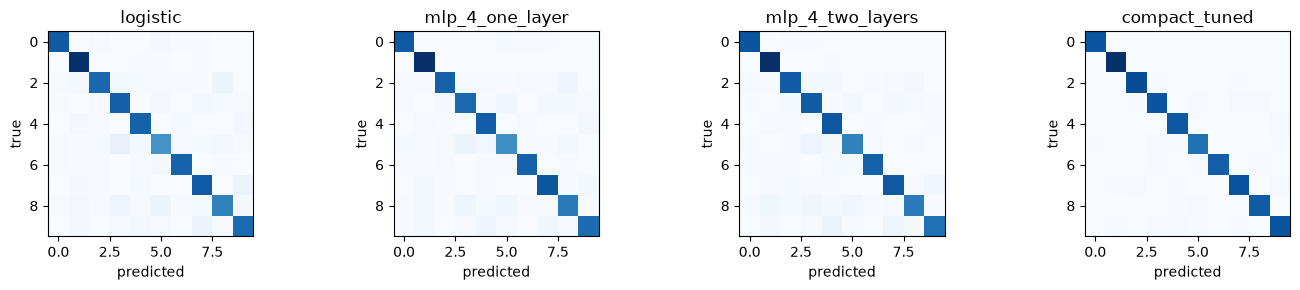

In [4]:
fig, axes = plt.subplots(1, len(trained), figsize=(3.5 * len(trained), 3))
if len(trained) == 1:
    axes = [axes]
for axis, (model_id, model) in zip(axes, trained.items()):
    matrix = confusion_matrix(y_test, model.predict(X_test))
    axis.imshow(matrix, cmap='Blues')
    axis.set_title(model_id)
    axis.set_xlabel('predicted')
    axis.set_ylabel('true')
plt.tight_layout()
plt.show()

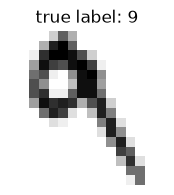

logistic → 5 35.63%
mlp_4_one_layer → 4 54.09%
mlp_4_two_layers → 4 72.52%
compact_tuned → 9 100.00%


In [5]:
sample_index = 7
plt.figure(figsize=(2, 2))
plt.imshow(X_test_pixels[sample_index].reshape(PIXEL_SIZE, PIXEL_SIZE), cmap='gray_r', vmin=0, vmax=16)
plt.title(f'true label: {y_test[sample_index]}')
plt.axis('off')
plt.show()
for model_id, model in trained.items():
    probabilities = model.predict_proba(X_test[sample_index:sample_index + 1])[0]
    print(model_id, '→', int(np.argmax(probabilities)), f'{probabilities.max():.2%}')

## Export artifact cho web

In [6]:
baseline_predictions = trained['logistic'].predict(X_test)
strong_ann_id = [model_id for model_id, cfg in model_configs.items() if cfg.get('kind') == 'ann'][-1]
tuned_predictions = trained[strong_ann_id].predict(X_test)
demo_sample_index = 0
for index, baseline_prediction, tuned_prediction, target in zip(
    range(len(y_test)), baseline_predictions, tuned_predictions, y_test
):
    if baseline_prediction != target and tuned_prediction == target:
        demo_sample_index = int(index)
        break

def make_metadata(model_id, name, kind, model, architecture, activations, hidden_act, source=None, source_url=None):
    return model_metadata(
        model_id, name, kind, model, architecture, activations,
        results[model_id]['test_accuracy'],
        results[model_id]['validation_accuracy'],
        hidden_act, source, source_url,
    )

def ann_display_name(model_id, model_config):
    hidden = list(hidden_layer_sizes(model_config))
    activation = hidden_activation(model_config)
    if len(hidden) == 1:
        return f'MLP · {hidden[0]} · {activation}'
    return f"MLP · {'×'.join(str(size) for size in hidden)} · {activation}"

models = []
for model_id, model_config in model_configs.items():
    if model_config.get('kind') == 'linear':
        models.append(make_metadata(
            model_id, 'Logistic Regression', 'linear', trained[model_id],
            architecture_sizes(model_config), [], None,
            'scikit-learn LogisticRegression',
            'https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html',
        ))
        continue
    models.append(make_metadata(
        model_id, ann_display_name(model_id, model_config), 'ann', trained[model_id],
        architecture_sizes(model_config), layer_activations(model_config), hidden_activation(model_config),
    ))

artifact = {
    'version': 4,
    'random_seed': config['random_seed'],
    'pixel_size': PIXEL_SIZE,
    'dataset': {
        'name': 'MNIST handwritten digits',
        'description': f'Real handwritten digit images from MNIST, normalized to {PIXEL_SIZE}x{PIXEL_SIZE} grayscale pixels for this demo.',
        'sample_count': 70000, 'training_sample_count': 60000, 'test_sample_count': 10000,
        'input_shape': [PIXEL_SIZE, PIXEL_SIZE], 'feature_count': PIXEL_COUNT, 'class_count': 10,
        'pixel_min': 0, 'pixel_max': 16, 'original_input_shape': [28, 28],
        'source_url': 'https://yann.lecun.com/exdb/mnist/',
    },
    'preprocessing': {
        'name': f'CropSquareResize{PIXEL_SIZE} + StandardScaler',
        'feature_transform': f'denoise at 50% of max ink, keep largest component, crop foreground, resize to square, area-average resize to {PIXEL_SIZE}x{PIXEL_SIZE}, scale intensity to 0..16',
        'mean': mean.tolist(), 'std': std.tolist(),
    },
    'fit_indices': config['fit_indices'], 'validation_indices': config['validation_indices'],
    'test_indices': config['test_indices'],
    'test_samples': np.rint(X_test_pixels).astype(int).tolist(),
    'test_labels': y_test.astype(int).tolist(),
    'demo_sample_index': demo_sample_index,
    'augmentation': {
        'enabled': AUGMENT_TRAINING,
        'factor': AUGMENT_FACTOR,
        'source_count': int(len(original_fit_pixels)),
        'generated_count': int(len(X_fit)),
        'variant_count': int(len(augmented_pixels)),
        'shift_pixels': AUGMENT_SHIFT_PIXELS,
        'stroke_variants': AUGMENT_STROKE_VARIANTS,
        'scale_range': list(AUGMENT_SCALE_RANGE),
        'rotate_degrees': AUGMENT_ROTATE_DEGREES,
        'sharpen': AUGMENT_SHARPEN,
        'applied_to': 'fit split only; validation and test remain unchanged',
    },
    'baseline_tuning': {
        'rounds': config['search']['logistic_rounds'],
        'C_candidates': [row['C'] for row in config['search']['logistic_candidates']],
        'selected_C': model_configs['logistic']['C'],
        'validation_accuracy': config['search']['selected_logistic_validation_accuracy'],
    },
    'models': models,
    'model_configs': {
        model_id: {
            'kind': model_config.get('kind'),
            'architecture': architecture_sizes(model_config),
            'activations': layer_activations(model_config),
        }
        for model_id, model_config in model_configs.items()
    },
    'strong_ann_id': strong_ann_id,
}
serialized_artifact = json.dumps(artifact, indent=2)
OUTPUT_PATH.write_text(serialized_artifact, encoding='utf-8')
WEB_OUTPUT_PATH.write_text(serialized_artifact, encoding='utf-8')
print(f'Wrote weights: {OUTPUT_PATH}')
print(f'Updated web artifact: {WEB_OUTPUT_PATH}')


Wrote weights: /Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02/gk/web/backend/artifacts/mnist_dataset/16x16/mnist_weights.json
Updated web artifact: /Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02/gk/web/backend/artifacts/digits_models_16x16.json
